In [29]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r'C:\Users\workstation\OneDrive\Desktop\My Paython\supply chain datatest\supply_chain_data.csv')
data.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [4]:

data.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [5]:
sales_pattren =data[['Product type','Price','Number of products sold','Revenue generated','Manufacturing costs','Costs','Customer demographics']]
sales_pattren.head()

,Product type,Price,Number of products sold,Revenue generated,Manufacturing costs,Costs,Customer demographics
0,haircare,69.808006,802,8661.996792,46.279879,187.752075,Non-binary
1,skincare,14.843523,736,7460.900065,33.616769,503.065579,Female
2,haircare,11.319683,8,9577.749626,30.688019,141.920282,Unknown
3,skincare,61.163343,83,7766.836426,35.624741,254.776159,Non-binary
4,skincare,4.805496,871,2686.505152,92.065161,923.440632,Non-binary


In [6]:
total_revenue=sales_pattren['Revenue generated'].sum()
total_revenue

np.float64(577604.8187380086)

In [7]:
sales_by_product=sales_pattren.groupby('Product type')['Number of products sold'].sum()
sales_by_product

Product type
cosmetics    11757
haircare     13611
skincare     20731
Name: Number of products sold, dtype: int64

In [8]:
revenue_by_product=sales_pattren.groupby('Product type')['Revenue generated'].sum()
revenue_by_product

Product type
cosmetics    161521.265999
haircare     174455.390605
skincare     241628.162133
Name: Revenue generated, dtype: float64

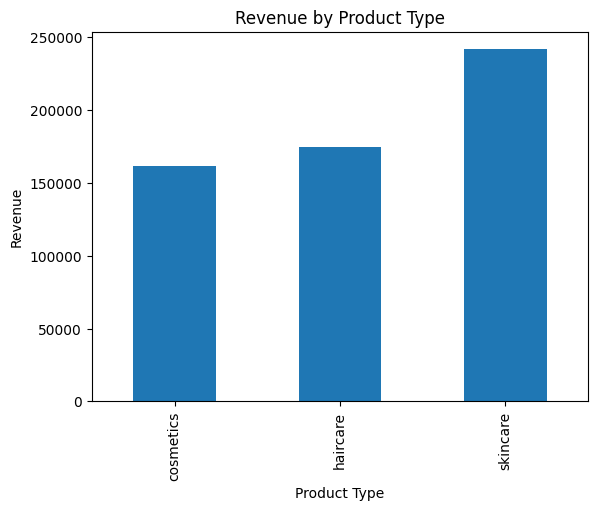

In [9]:
revenue_by_product.plot(kind="bar")
plt.title("Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Revenue")
plt.show()

In [10]:
sales_pattren['Customer demographics'].value_counts()


Customer demographics
Unknown       31
Female        25
Non-binary    23
Male          21
Name: count, dtype: int64

In [11]:
sales_pattren = sales_pattren[sales_pattren['Customer demographics'] != 'Unknown']

In [12]:
sales_by_gender_product = sales_pattren.groupby(
    ['Customer demographics', 'Product type']
)['Number of products sold'].sum()

print(sales_by_gender_product.unstack())

Product type           cosmetics  haircare  skincare
Customer demographics                               
Female                      4012       936      7853
Male                        2304      2292      2911
Non-binary                  2607      2820      5153


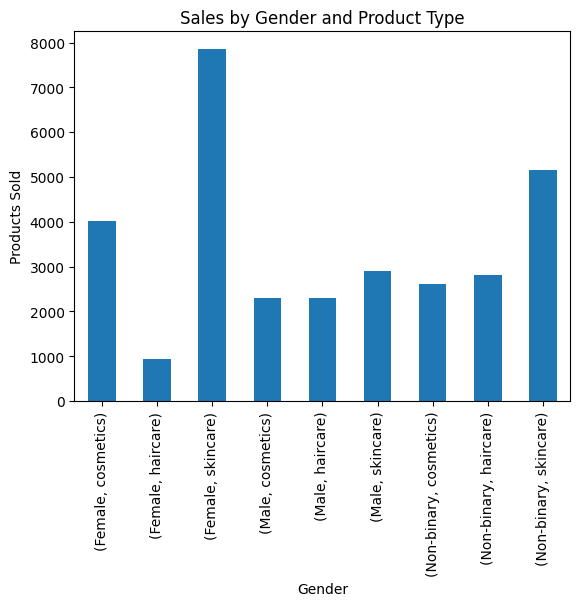

In [13]:
sales_by_gender_product.plot(kind='bar')


plt.title("Sales by Gender and Product Type")
plt.xlabel("Gender")
plt.ylabel("Products Sold")
plt.show()

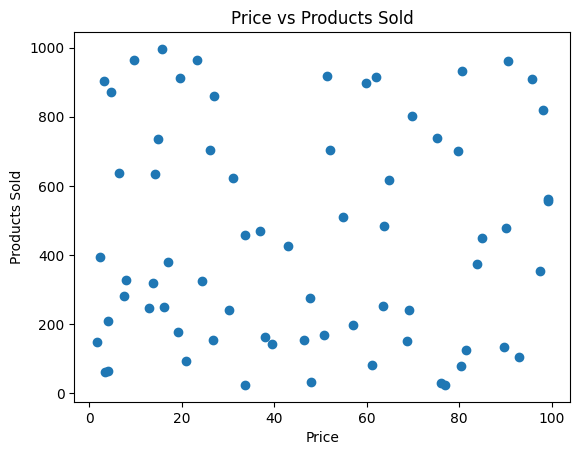

In [14]:
plt.scatter(sales_pattren["Price"], sales_pattren["Number of products sold"])

plt.title("Price vs Products Sold")
plt.xlabel("Price")
plt.ylabel("Products Sold")
plt.show()

In [15]:
sales_pattren['Profit']= sales_pattren['Revenue generated']-sales_pattren['Manufacturing costs']-sales_pattren['Costs']
sales_pattren[['Revenue generated','Manufacturing costs','Costs','Profit']]

,Revenue generated,Manufacturing costs,Costs,Profit
0,8661.996792,46.279879,187.752075,8427.964838
1,7460.900065,33.616769,503.065579,6924.217717
3,7766.836426,35.624741,254.776159,7476.435525
4,2686.505152,92.065161,923.440632,1670.999359
5,2828.348746,56.766476,235.461237,2536.121034
...,...,...,...,...
91,1935.206794,39.772883,996.778315,898.655596
92,2100.129755,62.612690,230.092783,1807.424282
96,7698.424766,17.803756,188.742141,7491.878868
97,4370.916580,65.765156,540.132423,3765.019001


In [16]:
profit_by_product=sales_pattren.groupby('Product type')['Profit'].sum()

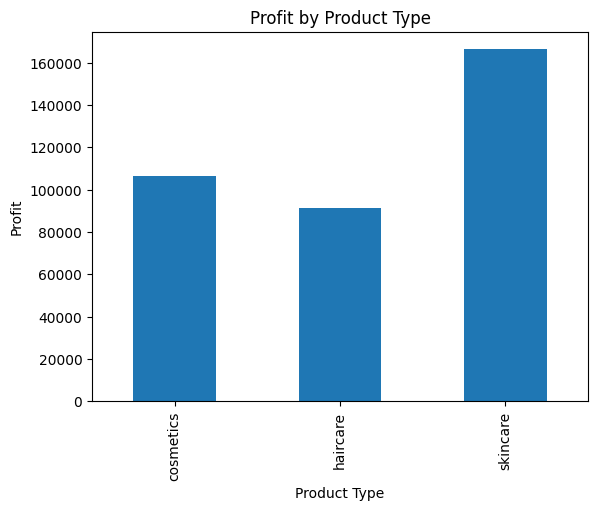

In [17]:
profit_by_product.plot(kind='bar')
plt.title("Profit by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Profit")
plt.show()

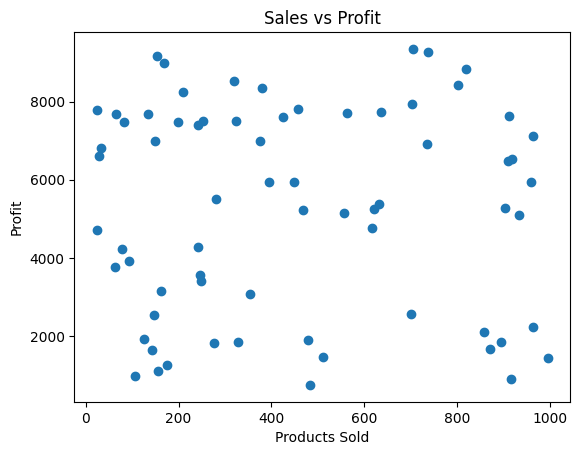

In [18]:
plt.scatter(
    sales_pattren['Number of products sold'],
    sales_pattren['Profit']
)

plt.xlabel("Products Sold")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [19]:
supplier_pattren = data[[
    "Supplier name",
    "Manufacturing costs",
    "Defect rates",
    "Inspection results",
    "Lead time"
]]

In [20]:
supplier_pattren.head()

,Supplier name,Manufacturing costs,Defect rates,Inspection results,Lead time
0,Supplier 3,46.279879,0.226410,Pending,29
1,Supplier 3,33.616769,4.854068,Pending,23
2,Supplier 1,30.688019,4.580593,Pending,12
3,Supplier 5,35.624741,4.746649,Fail,24
4,Supplier 1,92.065161,3.145580,Fail,5


In [21]:
supplier_pattren['Supplier name'].nunique()

5

In [22]:
cost_by_supplier = supplier_pattren.groupby('Supplier name')['Manufacturing costs'].mean()
print(cost_by_supplier)

Supplier name
Supplier 1    45.254027
Supplier 2    41.622514
Supplier 3    43.634121
Supplier 4    62.709727
Supplier 5    44.768243
Name: Manufacturing costs, dtype: float64


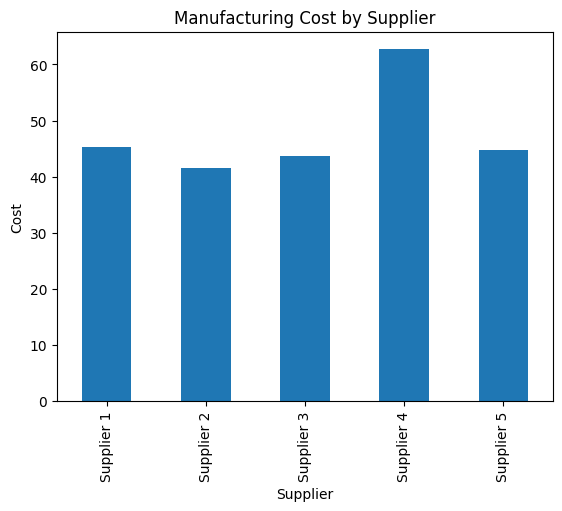

In [23]:
cost_by_supplier.plot(kind='bar')
plt.title("Manufacturing Cost by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Cost")
plt.show()

In [24]:
defect_by_supplier = supplier_pattren.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False)
print(defect_by_supplier)

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64


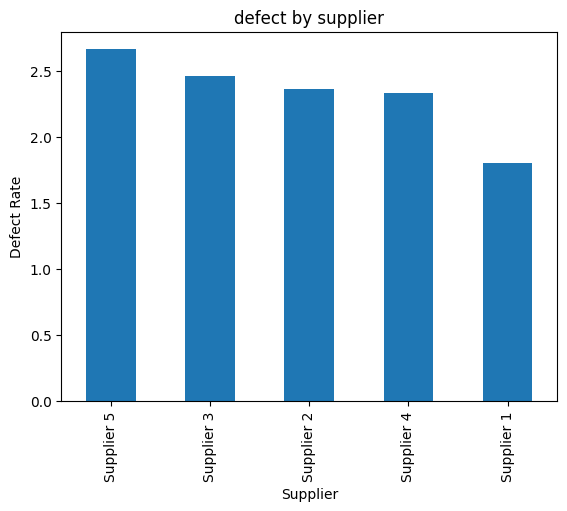

In [25]:
defect_by_supplier.plot(kind='bar')
plt.title('defect by supplier')
plt.xlabel('Supplier')
plt.ylabel("Defect Rate")
plt.show()

In [26]:
lead_time_supplier = supplier_pattren.groupby('Supplier name')['Lead time'].mean().sort_values(ascending=False)
print(lead_time_supplier)

Supplier name
Supplier 3    20.133333
Supplier 2    18.545455
Supplier 5    18.055556
Supplier 4    15.222222
Supplier 1    14.777778
Name: Lead time, dtype: float64


In [27]:
supplier_pattren['Category'] = 'Normal'

supplier_pattren.loc[
    (supplier_pattren['Manufacturing costs'] > 60) &
    (supplier_pattren['Defect rates'] > 3),
    'Category'
] = 'Bad Supplier'

supplier_pattren.loc[
    (supplier_pattren['Manufacturing costs'] < 40) &
    (supplier_pattren['Defect rates'] < 2),
    'Category'
] = 'Good Supplier'

C:\Users\workstation\AppData\Local\Temp\ipykernel_17096\1602853926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  supplier_pattren['Category'] = 'Normal'


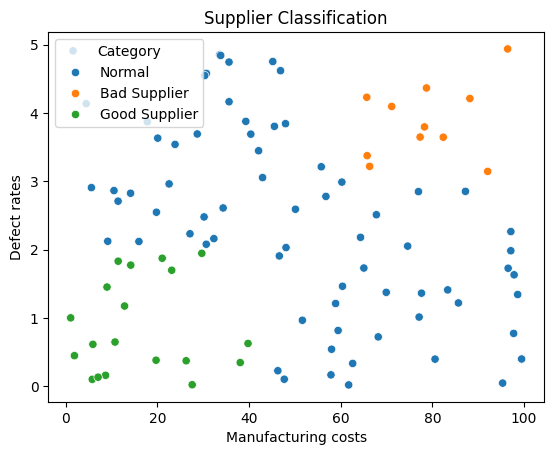

In [30]:
sns.scatterplot(
    data=supplier_pattren,
    x='Manufacturing costs',
    y='Defect rates',
    hue='Category'
)

plt.title("Supplier Classification")
plt.show()

In [ ]:
supplier_score = supplier_pattren.groupby('Supplier name').agg({
    'Manufacturing costs': 'mean',
    'Defect rates': 'mean',
    'Lead time': 'mean'
})

print(supplier_score)

               Manufacturing costs  Defect rates  Lead time
Supplier name                                              
Supplier 1               45.254027      1.803630  14.777778
Supplier 2               41.622514      2.362750  18.545455
Supplier 3               43.634121      2.465786  20.133333
Supplier 4               62.709727      2.337397  15.222222
Supplier 5               44.768243      2.665408  18.055556


In [35]:
supplier_score = supplier_pattren.groupby('Supplier name').agg({
    'Manufacturing costs': 'mean',
    'Defect rates': 'mean',
    'Lead time': 'mean'
})
    

In [36]:
supplier_score['Score'] = (
    supplier_score['Manufacturing costs'] * 0.3 +
    supplier_score['Defect rates'] * 0.5 +
    supplier_score['Lead time'] * 0.2
)

In [37]:
supplier_score = supplier_score.sort_values(by='Score')
print(supplier_score)

               Manufacturing costs  Defect rates  Lead time      Score
Supplier name                                                         
Supplier 2               41.622514      2.362750  18.545455  17.377220
Supplier 1               45.254027      1.803630  14.777778  17.433579
Supplier 3               43.634121      2.465786  20.133333  18.349796
Supplier 5               44.768243      2.665408  18.055556  18.374288
Supplier 4               62.709727      2.337397  15.222222  23.026061


In [38]:
best_supplier = supplier_score.index[0]
print("Best Supplier:", best_supplier)

Best Supplier: Supplier 2


In [40]:
shipping_pattren = data[[
    "Shipping carriers",
    "Shipping costs",
    "Shipping times",
    "Transportation modes",
    "Routes"
]]

In [41]:
shipping_pattren.head()

,Shipping carriers,Shipping costs,Shipping times,Transportation modes,Routes
0,Carrier B,2.956572,4,Road,Route B
1,Carrier A,9.716575,2,Road,Route B
2,Carrier B,8.054479,2,Air,Route C
3,Carrier C,1.729569,6,Rail,Route A
4,Carrier A,3.890548,8,Air,Route A


In [47]:
shipping_cost=shipping_pattren.groupby('Shipping carriers')['Shipping costs'].sum().sort_values(ascending=False)
shipping_cost

Shipping carriers
Carrier B    236.897620
Carrier C    162.379457
Carrier A    155.537831
Name: Shipping costs, dtype: float64

Transportation modes
Air     6.017839
Road    5.542115
Rail    5.469098
Sea     4.970294
Name: Shipping costs, dtype: float64


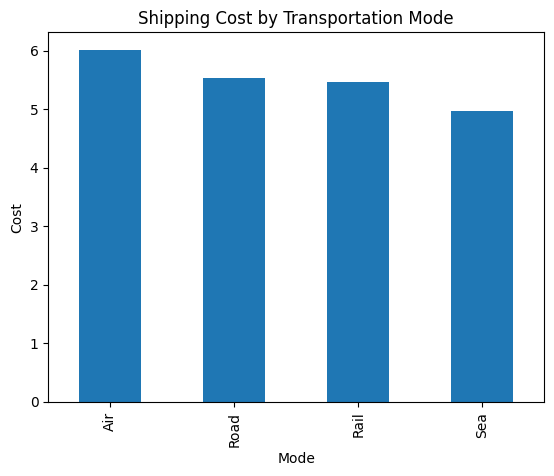

In [52]:
cost_by_mode = shipping_pattren.groupby('Transportation modes')['Shipping costs'].mean().sort_values(ascending=False)
print(cost_by_mode)
cost_by_mode.plot(kind='bar')
plt.title("Shipping Cost by Transportation Mode")
plt.xlabel("Mode")
plt.ylabel("Cost")
plt.show()

In [53]:
time_by_mode= shipping_pattren.groupby('Transportation modes')['Shipping times'].mean().sort_values(ascending=False)
time_by_mode

Transportation modes
Sea     7.117647
Rail    6.571429
Air     5.115385
Road    4.724138
Name: Shipping times, dtype: float64

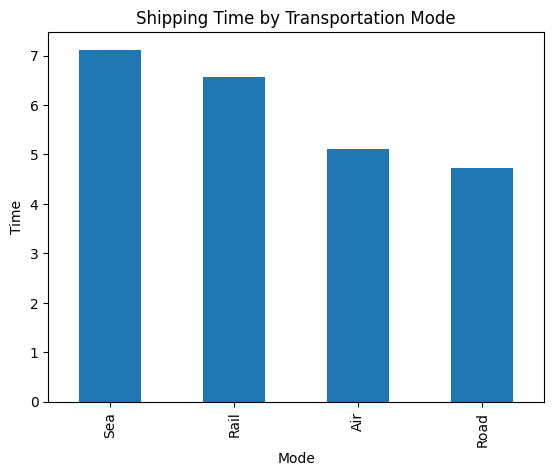

In [54]:
time_by_mode.plot(kind='bar')

plt.title("Shipping Time by Transportation Mode")
plt.xlabel("Mode")
plt.ylabel("Time")
plt.show()

In [58]:
carrier_performance = shipping_pattren.groupby('Shipping carriers').agg({
    'Shipping costs': 'mean',
    'Shipping times': 'mean'
})
carrier_performance

,Shipping costs,Shipping times
Shipping carriers,,
Carrier A,5.554923,6.142857
Carrier B,5.509247,5.302326
Carrier C,5.599292,6.034483


In [60]:
route_analysis = shipping_pattren.groupby('Routes')['Shipping costs'].mean()
route_analysis

Routes
Route A    5.379699
Route B    5.551986
Route C    5.903218
Name: Shipping costs, dtype: float64

In [62]:
shipping_score = shipping_pattren.groupby('Shipping carriers').agg({
    'Shipping costs': 'mean',
    'Shipping times': 'mean'
})

shipping_score['Score'] = (
    shipping_score['Shipping costs'] * 0.6 +
    shipping_score['Shipping times'] * 0.4
)

shipping_score = shipping_score.sort_values(by='Score')
shipping_score

,Shipping costs,Shipping times,Score
Shipping carriers,,,
Carrier B,5.509247,5.302326,5.426478
Carrier C,5.599292,6.034483,5.773368
Carrier A,5.554923,6.142857,5.790096


In [64]:
inventory_pattren = data[[
    "Product type",
    "Stock levels",
    "Order quantities",
    "Lead times"
]]
inventory_pattren.head()

,Product type,Stock levels,Order quantities,Lead times
0,haircare,58,96,7
1,skincare,53,37,30
2,haircare,1,88,10
3,skincare,23,59,13
4,skincare,5,56,3


In [66]:
order_by_product = inventory_pattren.groupby('Product type')['Order quantities'].mean()
order_by_product

Product type
cosmetics    51.653846
haircare     43.529412
skincare     52.475000
Name: Order quantities, dtype: float64

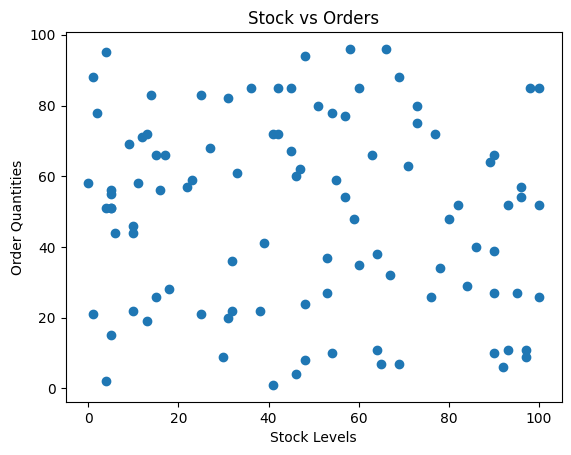

In [67]:
plt.scatter(
    inventory_pattren['Stock levels'],
    inventory_pattren['Order quantities']
)

plt.xlabel("Stock Levels")
plt.ylabel("Order Quantities")
plt.title("Stock vs Orders")
plt.show()

In [ ]:
low_stock = inventory_pattren[inventory_pattren['Stock levels'] < 20]
print(low_stock)

Product type        haircareskincareskincarecosmeticsskincareskinc...
Stock levels                                                      230
Order quantities                                                 1391
Lead times                                                        388
dtype: object


In [77]:
overstock = inventory_pattren[inventory_pattren['Stock levels'] > 100]
print(overstock)

Empty DataFrame
Columns: [Product type, Stock levels, Order quantities, Lead times]
Index: []


In [79]:
lead_time_analysis = inventory_pattren.groupby('Product type')['Lead times'].mean().sort_values(ascending=False)
print(lead_time_analysis)

Product type
skincare     16.700000
haircare     15.529412
cosmetics    15.384615
Name: Lead times, dtype: float64


In [80]:
inventory_pattren['Status'] = 'Normal'

inventory_pattren.loc[
    (inventory_pattren['Stock levels'] < 20),
    'Status'
] = 'Low Stock'

inventory_pattren.loc[
    (inventory_pattren['Stock levels'] > 100),
    'Status'
] = 'Overstock'

C:\Users\workstation\AppData\Local\Temp\ipykernel_17096\2391118166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inventory_pattren['Status'] = 'Normal'


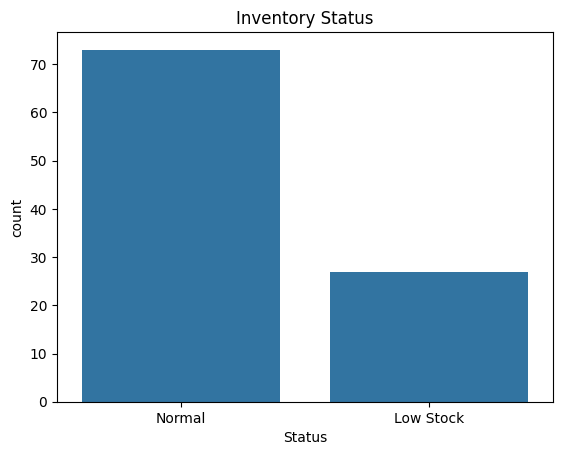

In [82]:
sns.countplot(data=inventory_pattren, x='Status')

plt.title("Inventory Status")
plt.show()